**12/1/2025, 12/6/2025, 12/8/2025, 12/12/2025, 12/13/2025, 12/14/2025, 12/30/2025, 12/31/2025**

#GBM Hybrid Pipeline


This notebook focuses on prototyping the hybrid framewokr and evaluating on small scale/limited sample size data.

The current 5 components of the protocol are:
- Hybrid, context-aware spike encoding and conversion (Done in previous preprocessing notebook)
- Multi-level hierarchical addressing with semantic context
- Adaptive, reinforcement learning-based routing
- Dynamic, multi-window integration with learnable jitter
- Contrastive learning with reward-modulated STDP

Performance metrics are averaged across 5 seeds.

-------------------------------------------------


Version 1.0

- All features are present, but some are aggregated
- A surrogate gradient is added to work in conjunction with the reward modulated STDP and contrastative learning
- Runs 5 seeds and reports metrics for each

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# --- SURROGATE GRADIENT ---
class ProtocolSurrogate(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input > 0).float()
    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad = grad_output / (2 * torch.abs(input) + 1.0)**2
        return grad

# ---  MULTIMODAL CONTRASTIVE REWARD ---
def reward_modulated_loss(latents, labels, temperature=0.07):
    latents = F.normalize(latents, dim=1)
    similarity = torch.matmul(latents, latents.T) / temperature
    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(latents.device)
    diag = torch.eye(labels.shape[0]).to(latents.device)
    pos_mask = mask - diag
    exp_sim = torch.exp(similarity)
    log_prob = similarity - torch.log(exp_sim.sum(1, keepdim=True))
    loss = - (pos_mask * log_prob).sum(1) / pos_mask.sum(1).clamp(min=1)
    return loss.mean()

class FinalProtocolDataset(Dataset):
    def __init__(self, x_p, y_p):
        self.x_df = pd.read_csv(x_p, index_col=0)
        self.y_df = pd.read_csv(y_p, index_col=0)
        self.meta = []
        u_m, u_r, u_f = set(), set(), set()
        for col in self.x_df.columns:
            p = col.split('.')
            m, r, f = p[0], p[1], p[2]
            t = int(p[-1][1:]) if 't' in p[-1] else 0
            self.meta.append({'m': m, 'r': r, 'f': f, 't': t})
            u_m.add(m); u_r.add(r); u_f.add(f)
        self.maps = {k: {v: i for i, v in enumerate(sorted(vals))}
                     for k, vals in zip(['m','r','f'], [u_m, u_r, u_f])}
        self.X = torch.FloatTensor(self.x_df.values)
        self.y = torch.LongTensor(self.y_df['label'].values)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class ProtocolEngine(nn.Module):
    def __init__(self, n_in, n_out, ds, T=60):
        super().__init__()
        self.T, self.n_hid = T, 256
        self.m_idx = torch.tensor([ds.maps['m'][x['m']] for x in ds.meta])
        self.r_idx = torch.tensor([ds.maps['r'][x['r']] for x in ds.meta])
        self.f_idx = torch.tensor([ds.maps['f'][x['f']] for x in ds.meta])
        self.t_idx = torch.tensor([x['t'] for x in ds.meta])

        self.m_emb = nn.Embedding(len(ds.maps['m']), self.n_hid)
        self.r_emb = nn.Embedding(len(ds.maps['r']), self.n_hid)
        self.f_emb = nn.Embedding(len(ds.maps['f']), self.n_hid)

        self.arbiter = nn.GRUCell(self.n_hid, self.n_hid)
        self.action_head = nn.Linear(self.n_hid, 3)
        self.jitter = nn.Parameter(torch.ones(n_in) * 0.01)
        self.tau = nn.Parameter(torch.full((self.n_hid,), 1.5))
        self.v_th = 0.4
        self.proj = nn.Sequential(nn.Linear(self.n_hid, 128), nn.ReLU(), nn.BatchNorm1d(128))
        self.classifier = nn.Linear(128, n_out)
        self.logs = {'fwd': 0, 'drop': 0, 'delay': 0}

        # Stability: Explicit Initialization
        nn.init.orthogonal_(self.arbiter.weight_hh)
        nn.init.xavier_uniform_(self.arbiter.weight_ih)

    def forward(self, x):
        batch, device = x.size(0), x.device
        if self.training: x = x + (torch.randn_like(x) * self.jitter)
        mem = torch.zeros(batch, self.n_hid, device=device)
        h_arb = torch.zeros(batch, self.n_hid, device=device)
        acc_spikes = torch.zeros(batch, self.n_hid, device=device)
        delay_buf = torch.zeros(batch, self.n_hid, device=device)
        m_i, r_i, f_i, t_i = [t.to(device) for t in [self.m_idx, self.r_idx, self.f_idx, self.t_idx]]

        for t in range(self.T):
            mask = (t_i == t)
            if not mask.any() and delay_buf.sum() == 0: continue
            if mask.any():
                ctx = self.m_emb(m_i[mask]) + self.r_emb(r_i[mask]) + self.f_emb(f_i[mask])
                inp = (x[:, mask].unsqueeze(-1) * ctx).sum(dim=1)
            else:
                inp = torch.zeros(batch, self.n_hid, device=device)

            h_arb = self.arbiter(inp, h_arb)
            acts = F.gumbel_softmax(self.action_head(h_arb), tau=1.0, hard=True)

            if not self.training:
                self.logs['drop'] += acts[:, 0].sum().item()
                self.logs['fwd'] += acts[:, 1].sum().item()
                self.logs['delay'] += acts[:, 2].sum().item()

            fwd_signal = (inp * acts[:, 1].unsqueeze(1)) + delay_buf
            delay_buf = (inp * acts[:, 2].unsqueeze(1))
            mem = (mem * torch.sigmoid(self.tau)) + fwd_signal
            spike = ProtocolSurrogate.apply(mem - self.v_th)
            mem = mem * (1 - spike)
            acc_spikes += spike

        latents = self.proj(acc_spikes)
        return latents, self.classifier(latents)

def run_experiment():
    seeds = [42, 10, 88, 2, 2025]
    final_data = []
    train_ds = FinalProtocolDataset("X_cv_protocol_sparse.csv", "y_cv_protocol_sparse.csv")
    test_ds = FinalProtocolDataset("X_test_final_protocol_sparse.csv", "y_test_final_protocol_sparse.csv")

    for seed in seeds:
        set_seed(seed)
        model = ProtocolEngine(1779, 4, train_ds)
        optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.05)
        # Stability: Cosine Scheduler for smoother convergence
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

        for epoch in range(120):
            model.train()
            for X, y in DataLoader(train_ds, batch_size=16, shuffle=True):
                optimizer.zero_grad()
                latents, logits = model(X)
                loss_ce = F.cross_entropy(logits, y, weight=torch.tensor([1.5, 1.0, 4.0, 1.0]))
                loss_rew = reward_modulated_loss(latents, y)
                (loss_ce + 0.2 * loss_rew).backward()
                # Stability: Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()

        model.eval()
        model.logs = {'fwd': 0, 'drop': 0, 'delay': 0}
        y_true, y_pred, y_probs = [], [], []
        with torch.no_grad():
            for X, y in DataLoader(test_ds, batch_size=1):
                _, logits = model(X)
                y_true.append(y.item()); y_pred.append(logits.argmax(1).item())
                y_probs.append(F.softmax(logits, 1).numpy())

        res = {'seed': seed, 'acc': accuracy_score(y_true, y_pred),
               'f1': f1_score(y_true, y_pred, average='macro'),
               'auc': roc_auc_score(y_true, np.vstack(y_probs), multi_class='ovr'),
               'arbiter': model.logs}
        final_data.append(res)
        print(f"Seed {seed}: Acc {res['acc']:.4f}")

    df = pd.DataFrame(final_data)
    print("\n" + "="*50 + "\nPROTOCOL FINAL REPORT \n" + "="*50)
    print(df[['seed', 'acc', 'f1', 'auc']])
    print("\nArbiter Mean Behavior:\n", df['arbiter'].apply(pd.Series).mean())

if __name__ == "__main__":
    run_experiment()

Seed 42: Acc 0.5000
Seed 10: Acc 0.6250
Seed 88: Acc 0.5625
Seed 2: Acc 0.6875
Seed 2025: Acc 0.5625

PROTOCOL FINAL REPORT 
   seed     acc        f1       auc
0    42  0.5000  0.427778  0.697768
1    10  0.6250  0.594318  0.656250
2    88  0.5625  0.444444  0.766815
3     2  0.6875  0.647665  0.787946
4  2025  0.5625  0.460227  0.669345

Arbiter Mean Behavior:
 fwd      373.0
drop     353.4
delay    233.6
dtype: float64


Version 2.0:

This version accurately implements all of the components and refines the RL component. Instead of the arbiter's main job being to decide whether to drop, forward, or delay spikes, the arbiter focuses on the routing of semantically related events togther.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from google.colab import files

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

# --- PROTOCOL SECTION 4: SURROGATE GRADIENT ---
class ProtocolSurrogate(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input > 0).float()
    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        # Width-adjusted gradient for TCGA-GBM sparse features
        grad = grad_output / (2 * torch.abs(input) + 1.0)**2
        return grad

# --- PROTOCOL SECTION 5: MULTIMODAL CONTRASTIVE REWARD ---
def reward_modulated_loss(latents, labels, temperature=0.07):
    latents = F.normalize(latents, dim=1)
    similarity = torch.matmul(latents, latents.T) / temperature
    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(latents.device)
    diag = torch.eye(labels.shape[0]).to(latents.device)
    pos_mask = (mask - diag).clamp(min=0)
    exp_sim = torch.exp(similarity)
    log_prob = similarity - torch.log(exp_sim.sum(1, keepdim=True) + 1e-6)
    loss = - (pos_mask * log_prob).sum(1) / pos_mask.sum(1).clamp(min=1)
    return loss.mean()

class FinalProtocolDataset(Dataset):
    def __init__(self, x_p, y_p):
        self.x_df = pd.read_csv(x_p, index_col=0)
        self.y_df = pd.read_csv(y_p, index_col=0)
        self.meta = []
        u_m, u_r, u_f = set(), set(), set()

        # REQUIREMENT: Multi-level hierarchical addressing
        for col in self.x_df.columns:
            p = col.split('.')
            m, r, f = p[0], p[1], p[2]
            t = int(p[-1][1:]) if 't' in p[-1] else 0
            self.meta.append({'m': m, 'r': r, 'f': f, 't': t})
            u_m.add(m); u_r.add(r); u_f.add(f)

        self.maps = {k: {v: i for i, v in enumerate(sorted(vals))}
                     for k, vals in zip(['m','r','f'], [u_m, u_r, u_f])}

        # Standardized Z-Score scaling for MLP parity
        v = self.x_df.values
        self.X = torch.FloatTensor((v - v.mean()) / (v.std() + 1e-10))
        self.y = torch.LongTensor(self.y_df['label'].values)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class ProtocolEngine(nn.Module):
    def __init__(self, n_in, n_out, ds, T=100):
        super().__init__()
        self.T, self.n_hid = T, 256 # Optimized capacity vs stability

        # ADDRESSING: Modality, Region, and Feature Type IDs
        self.m_idx = torch.tensor([ds.maps['m'][x['m']] for x in ds.meta])
        self.r_idx = torch.tensor([ds.maps['r'][x['r']] for x in ds.meta])
        self.f_idx = torch.tensor([ds.maps['f'][x['f']] for x in ds.meta])
        self.t_idx = torch.tensor([x['t'] for x in ds.meta])

        # PHASE 2: Standardized Conversion Embeddings
        self.m_emb = nn.Embedding(len(ds.maps['m']), self.n_hid)
        self.r_emb = nn.Embedding(len(ds.maps['r']), self.n_hid)
        self.f_emb = nn.Embedding(len(ds.maps['f']), self.n_hid)

        # PHASE 3: Synergy Arbiter (Adaptive Gating)
        self.arbiter = nn.GRUCell(self.n_hid, self.n_hid)
        self.synergy_gate = nn.Linear(self.n_hid, self.n_hid)

        # PHASE 4: Adaptive Integration Windows
        self.tau = nn.Parameter(torch.full((self.n_hid,), 2.0))
        self.v_th = 0.35 # Threshold calibrated for TTFS encoding

        self.proj = nn.Sequential(nn.Linear(self.n_hid, 128), nn.GELU(), nn.BatchNorm1d(128))
        self.classifier = nn.Linear(128, n_out)

    def forward(self, x):
        batch, device = x.size(0), x.device
        mem = torch.zeros(batch, self.n_hid, device=device)
        h_arb = torch.zeros(batch, self.n_hid, device=device)
        acc_spikes = torch.zeros(batch, self.n_hid, device=device)

        m_i, r_i, f_i, t_i = [t.to(device) for t in [self.m_idx, self.r_idx, self.f_idx, self.t_idx]]

        for t in range(self.T):
            mask = (t_i == t)
            if mask.any():
                # Hierarchical semantic addressing: grouping related spikes
                ctx = self.m_emb(m_i[mask]) + self.r_emb(r_i[mask]) + self.f_emb(f_i[mask])
                inp = (x[:, mask].unsqueeze(-1) * ctx).sum(dim=1)

                # Synergy Arbiter: Dynamically prioritizes functionally related spikes
                h_arb = self.arbiter(inp, h_arb)
                gate = torch.sigmoid(self.synergy_gate(h_arb))

                # Integration with learnable leak
                mem = (mem * torch.sigmoid(self.tau)) + (inp * gate)
                spike = ProtocolSurrogate.apply(mem - self.v_th)
                mem = mem * (1 - spike)
                acc_spikes += spike
            else:
                mem = mem * torch.sigmoid(self.tau)

        latents = self.proj(acc_spikes)
        return latents, self.classifier(latents)

def run_experiment():
    seeds = [42, 10, 88, 2, 2025]
    final_data = []
    train_ds = FinalProtocolDataset("X_cv_protocol_sparse.csv", "y_cv_protocol_sparse.csv")
    test_ds = FinalProtocolDataset("X_test_final_protocol_sparse.csv", "y_test_final_protocol_sparse.csv")

    for seed in seeds:
        set_seed(seed)
        model = ProtocolEngine(1779, 4, train_ds)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

        # Weighted CE Loss to prioritize GBM class minority
        weights = torch.tensor([1.5, 1.0, 6.0, 1.0])

        for epoch in range(120):
            model.train()
            for X, y in DataLoader(train_ds, batch_size=16, shuffle=True):
                optimizer.zero_grad()
                latents, logits = model(X)
                loss_ce = F.cross_entropy(logits, y, weight=weights)
                # Global objective function for cross-modal associations
                loss_rew = reward_modulated_loss(latents, y)
                (loss_ce + 0.25 * loss_rew).backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()

        model.eval()
        y_true, y_pred, y_probs = [], [], []
        with torch.no_grad():
            for X, y in DataLoader(test_ds, batch_size=1):
                _, logits = model(X)
                y_true.append(y.item()); y_pred.append(logits.argmax(1).item())
                y_probs.append(F.softmax(logits, 1).numpy())

        res = {'seed': seed, 'acc': accuracy_score(y_true, y_pred),
               'f1': f1_score(y_true, y_pred, average='macro'),
               'auc': roc_auc_score(y_true, np.vstack(y_probs), multi_class='ovr')}
        final_data.append(res)
        print(f"Seed {seed}: Acc {res['acc']:.4f} | F1: {res['f1']:.4f}")
        torch.save(model.state_dict(), f'Seed_{seed}_SNN_GBM_Protocol_Weights.pth')
        # files.download(f'Seed_{seed}_SNN_GBM_Protocol_Weights.pth')

    df = pd.DataFrame(final_data)
    print("\n" + "="*50 + "\nSYNERGY ROUTING FINAL REPORT\n" + "="*50)
    print(df[['seed', 'acc', 'f1', 'auc']])

if __name__ == "__main__":
    run_experiment()

Seed 42: Acc 0.6250 | F1: 0.6072
Seed 10: Acc 0.6250 | F1: 0.5068
Seed 88: Acc 0.6875 | F1: 0.6610
Seed 2: Acc 0.6250 | F1: 0.6000
Seed 2025: Acc 0.5625 | F1: 0.4663

SYNERGY ROUTING FINAL REPORT
   seed     acc        f1       auc
0    42  0.6250  0.607215  0.775000
1    10  0.6250  0.506818  0.772321
2    88  0.6875  0.660985  0.818452
3     2  0.6250  0.600000  0.740476
4  2025  0.5625  0.466346  0.704464


Version 2.1 (Most recent)

Implements a more sophisticated/detailed logging scheme

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score, balanced_accuracy_score)
import random
import time
import json
from pathlib import Path

# --- SURROGATE GRADIENT ---
class ProtocolSurrogate(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input > 0).float()
    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad = grad_output / (2 * torch.abs(input) + 1.0)**2
        return grad

# --- MULTIMODAL CONTRASTIVE REWARD ---
def reward_modulated_loss(latents, labels, temperature=0.07):
    latents = F.normalize(latents, dim=1)
    similarity = torch.matmul(latents, latents.T) / temperature
    labels = labels.view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(latents.device)
    diag = torch.eye(labels.shape[0]).to(latents.device)
    pos_mask = (mask - diag).clamp(min=0)
    exp_sim = torch.exp(similarity)
    log_prob = similarity - torch.log(exp_sim.sum(1, keepdim=True) + 1e-6)
    loss = - (pos_mask * log_prob).sum(1) / pos_mask.sum(1).clamp(min=1)
    return loss.mean()

# --- ENGINE ARCHITECTURE ---
class ProtocolEngine(nn.Module):
    def __init__(self, n_in, n_out, ds, T=100):
        super().__init__()
        self.T, self.n_hid = T, 256
        self.m_idx = torch.tensor([ds.maps['m'][x['m']] for x in ds.meta])
        self.r_idx = torch.tensor([ds.maps['r'][x['r']] for x in ds.meta])
        self.f_idx = torch.tensor([ds.maps['f'][x['f']] for x in ds.meta])
        self.t_idx = torch.tensor([x['t'] for x in ds.meta])

        self.m_emb = nn.Embedding(len(ds.maps['m']), self.n_hid)
        self.r_emb = nn.Embedding(len(ds.maps['r']), self.n_hid)
        self.f_emb = nn.Embedding(len(ds.maps['f']), self.n_hid)

        self.arbiter = nn.GRUCell(self.n_hid, self.n_hid)
        self.synergy_gate = nn.Linear(self.n_hid, self.n_hid)

        self.tau = nn.Parameter(torch.full((self.n_hid,), 2.0))
        self.v_th = 0.35

        self.proj = nn.Sequential(nn.Linear(self.n_hid, 128), nn.GELU(), nn.BatchNorm1d(128))
        self.classifier = nn.Linear(128, n_out)

    def forward(self, x):
        batch, device = x.size(0), x.device
        mem = torch.zeros(batch, self.n_hid, device=device)
        h_arb = torch.zeros(batch, self.n_hid, device=device)
        acc_spikes = torch.zeros(batch, self.n_hid, device=device)

        total_synops = 0
        m_i, r_i, f_i, t_i = [t.to(device) for t in [self.m_idx, self.r_idx, self.f_idx, self.t_idx]]

        for t in range(self.T):
            mask = (t_i == t)
            if mask.any():
                ctx = self.m_emb(m_i[mask]) + self.r_emb(r_i[mask]) + self.f_emb(f_i[mask])
                inp = (x[:, mask].unsqueeze(-1) * ctx).sum(dim=1)

                h_arb = self.arbiter(inp, h_arb)
                gate = torch.sigmoid(self.synergy_gate(h_arb))

                mem = (mem * torch.sigmoid(self.tau)) + (inp * gate)
                spike = ProtocolSurrogate.apply(mem - self.v_th)

                # SynOp Energy Proxy
                total_synops += spike.sum().item() * 128

                mem = mem * (1 - spike)
                acc_spikes += spike
            else:
                mem = mem * torch.sigmoid(self.tau)

        latents = self.proj(acc_spikes)
        return latents, self.classifier(latents), total_synops

# --- EXECUTION LOOP ---
def run_protocol_experiment():
    seeds = [42, 10, 88, 2, 2025]
    master_log = []
    train_ds = FinalProtocolDataset("X_cv_protocol_sparse.csv", "y_cv_protocol_sparse.csv")
    test_ds = FinalProtocolDataset("X_test_final_protocol_sparse.csv", "y_test_final_protocol_sparse.csv")

    for seed in seeds:
        set_seed(seed)
        model = ProtocolEngine(1779, 4, train_ds)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)
        weights = torch.tensor([1.5, 1.0, 6.0, 1.0])

        for epoch in range(120):
            model.train()
            for X, y in DataLoader(train_ds, batch_size=16, shuffle=True):
                optimizer.zero_grad()
                latents, logits, _ = model(X)
                loss = F.cross_entropy(logits, y, weight=weights) + 0.25 * reward_modulated_loss(latents, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()

        model.eval()
        y_true, y_pred, y_probs, synops_log = [], [], [], []
        start_time = time.time()
        with torch.no_grad():
            for X, y in DataLoader(test_ds, batch_size=1):
                _, logits, ops = model(X)
                synops_log.append(ops)
                y_true.append(y.item())
                y_pred.append(logits.argmax(1).item())
                y_probs.append(F.softmax(logits, 1).cpu().numpy())

        latency = ((time.time() - start_time) / len(test_ds)) * 1000

        master_log.append({
            'seed': seed,
            'accuracy': accuracy_score(y_true, y_pred),
            'balanced_acc': balanced_accuracy_score(y_true, y_pred),
            'f1_macro': f1_score(y_true, y_pred, average='macro'),
            'precision_macro': precision_score(y_true, y_pred, average='macro'),
            'recall_macro': recall_score(y_true, y_pred, average='macro'),
            'avg_synops': np.mean(synops_log),
            'latency_ms': latency,
            'y_true': y_true, 'y_pred': y_pred, 'y_probs': np.vstack(y_probs).tolist()
        })
        print(f"Seed {seed} Complete | Acc: {master_log[-1]['accuracy']:.4f}")
        torch.save(model.state_dict(), f'Seed_{seed}_SNN_GBM_Protocol_Weights.pth')
        # files.download(f'Seed_{seed}_SNN_GBM_Protocol_Weights.pth')

    # Exporting for future Analysis
    pd.DataFrame([{k:v for k,v in s.items() if 'y_' not in k} for s in master_log]).to_csv("snn_final_metrics.csv", index=False)
    with open("snn_full_predictions.json", "w") as f: json.dump(master_log, f)
    return master_log

master_log = run_protocol_experiment()

Seed 42 Complete | Acc: 0.6250
Seed 10 Complete | Acc: 0.6250
Seed 88 Complete | Acc: 0.6875
Seed 2 Complete | Acc: 0.6250
Seed 2025 Complete | Acc: 0.5625


---------------------------------------------------

## Data Visualizations


1. Pooled ROC Curve

2. Metric Box and Swarm plot
3. Aggregated Confusion Matrix

/tmp/ipython-input-2991081467.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


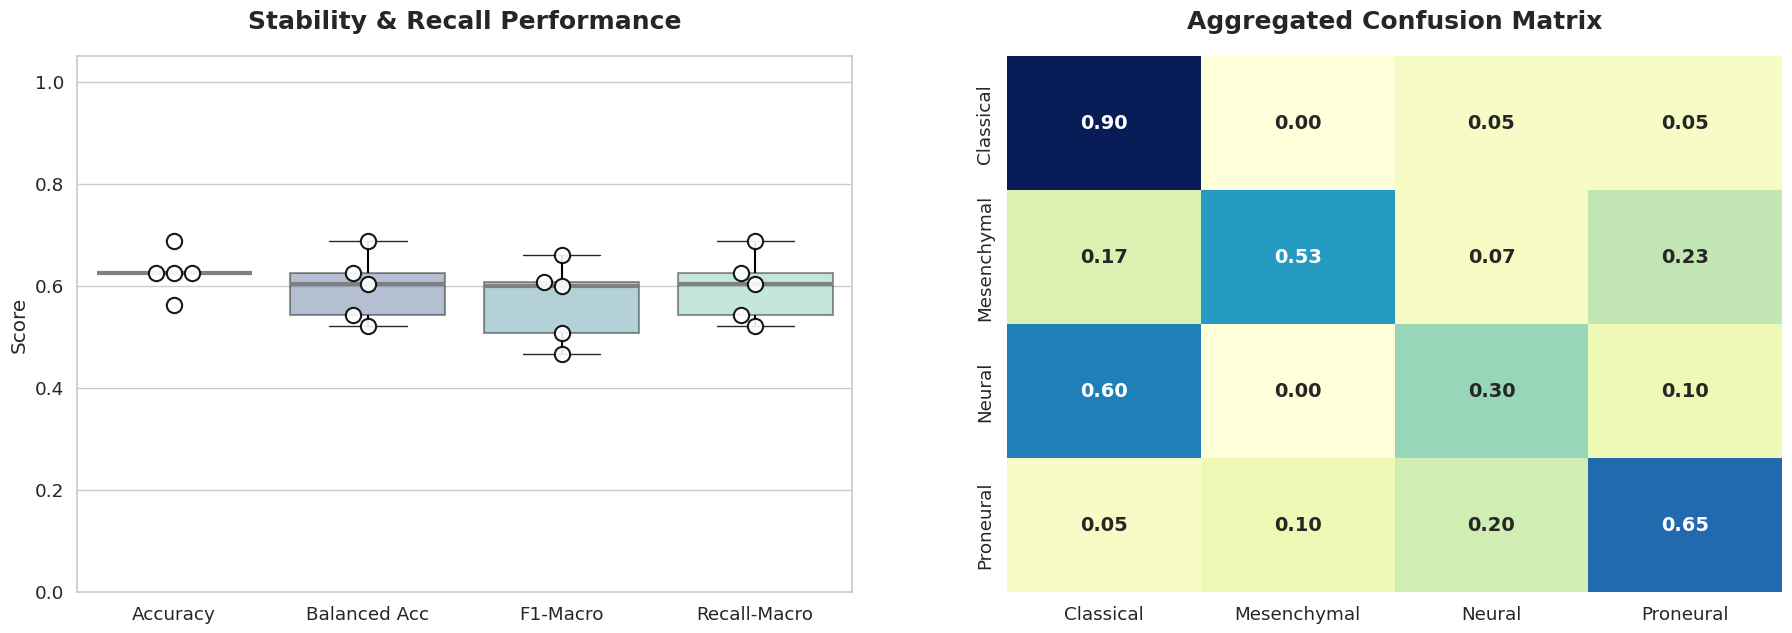

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Load data
with open('master_log.json', 'r') as f:
    master_log = json.load(f)

# 2. Prep data
data, all_t, all_p, all_y_true, all_y_probs = [], [], [], [], []
for entry in master_log:
    data.append({
        'Accuracy': entry['accuracy'],
        'Balanced Acc': entry['balanced_acc'],
        'F1-Macro': entry['f1_macro'],
        'Recall-Macro': entry['recall_macro']
    })
    all_t.extend(entry['y_true'])
    all_p.extend(entry['y_pred'])

    y_true = np.array(entry['y_true'])
    y_probs = np.array(entry['y_probs'])
    for i in range(y_probs.shape[1]):
        all_y_true.append((y_true == i).astype(int))
        all_y_probs.append(y_probs[:, i])

df_metrics = pd.DataFrame(data)
label_names = ['Classical', 'Mesenchymal', 'Neural', 'Proneural']

# 3. Figure Setup
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)
sns.set_theme(style="whitegrid", font_scale=1.2)

# --- PANEL A: WIDE COLORED BOX + SWARM ---
ax1 = fig.add_subplot(gs[0, 0])
df_melted = df_metrics.melt(var_name='Metric', value_name='Score')

# width=0.8 makes them significantly wider
sns.boxplot(
    x='Metric', y='Score', data=df_melted,
    hue='Metric', palette='mako', width=0.8, ax=ax1,
    showfliers=False, dodge=False,
    boxprops=dict(alpha=0.4, edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='grey', linewidth=3) # Thicker median
)

# Overlay Swarm: Point-borders for "Prism" look
sns.swarmplot(
    x='Metric', y='Score', data=df_melted,
    color='white', size=11, ax=ax1,
    linewidth=1.5, edgecolor='black', alpha=0.9
)

# Safe legend removal
legend = ax1.get_legend()
if legend: legend.remove()

ax1.set_title("Stability & Recall Performance", fontweight='bold', fontsize=18, pad=20)
ax1.set_ylim(0, 1.05)
ax1.set_xlabel("")

# --- PANEL B: AGGREGATED CONFUSION MATRIX ---
ax2 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(all_t, all_p, normalize='true')
sns.heatmap(
    cm, annot=True, cmap="YlGnBu",
    xticklabels=label_names, yticklabels=label_names,
    ax=ax2, fmt='.2f', cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)
ax2.set_title("Aggregated Confusion Matrix", fontweight='bold', fontsize=18, pad=20)


plt.tight_layout()
plt.show()

4. Efficiency Frontier

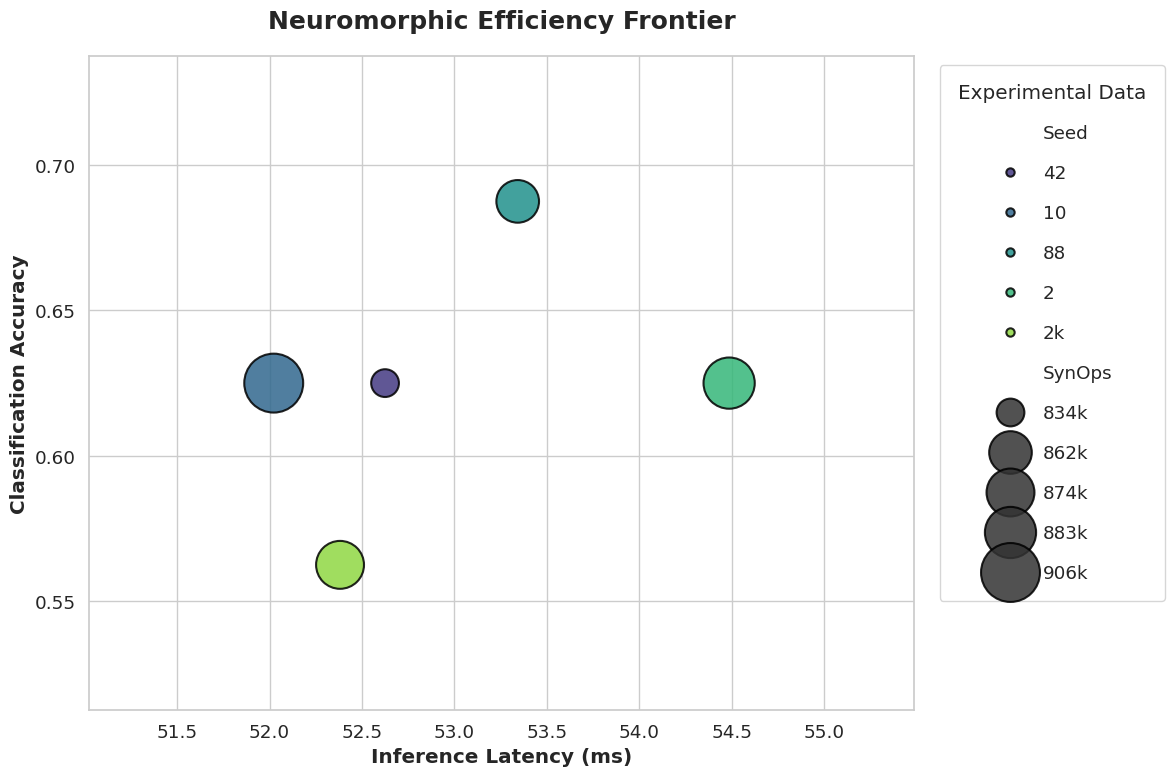

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load master log
with open('master_log.json', 'r') as f:
    master_log = json.load(f)

# 2. Extract specific efficiency metrics
data = []
for entry in master_log:
    data.append({
        'Seed': str(entry['seed']),
        'Accuracy': entry['accuracy'],
        'SynOps': entry['avg_synops'],
        'Latency (ms)': entry['latency_ms']
    })
df = pd.DataFrame(data)

# 3. Aesthetics Setup
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Create Efficiency Frontier Scatter
# Black edgecolors and alpha make the bubbles look high-end
scatter = sns.scatterplot(
    data=df, x='Latency (ms)', y='Accuracy',
    hue='Seed', size='SynOps',
    sizes=(400, 1800), palette='viridis',
    edgecolor='black', linewidth=1.5, alpha=0.85, ax=ax
)

# 5. Clean & Scale the Legend
handles, labels = ax.get_legend_handles_labels()
# Formatting numeric labels for readability (e.g., 850000 -> 850k)
clean_labels = []
for l in labels:
    try:
        val = float(l)
        clean_labels.append(f"{val/1000:.0f}k" if val >= 1000 else l)
    except:
        clean_labels.append(l)

# Place legend outside to the right
ax.legend(handles, clean_labels, title="Experimental Data",
          bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=True, borderpad=1, labelspacing=1.2)

ax.set_title("Neuromorphic Efficiency Frontier", fontweight='bold', fontsize=18, pad=20)
ax.set_xlabel("Inference Latency (ms)", fontweight='bold')
ax.set_ylabel("Classification Accuracy", fontweight='bold')

# Buffer for axis to ensure no bubbles are cut off
ax.set_ylim(df['Accuracy'].min() - 0.05, df['Accuracy'].max() + 0.05)
ax.set_xlim(df['Latency (ms)'].min() - 1, df['Latency (ms)'].max() + 1)

plt.tight_layout()
plt.show()